In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import xml.etree.ElementTree as ET
from constants import ImzMLFileParser

In [2]:
def read_ibm_file(path: str, sample_id: str, modality_name: str) -> tuple[np.ndarray, np.ndarray]:

    sample_path = os.path.join(path, sample_id)
    mod_path = os.path.join(sample_path, modality_name)

    # Check if the path exists
    if not os.path.exists(mod_path):
        raise FileNotFoundError(f"Path {mod_path} does not exist.")

    # List the files in the given directory and extract the absolute path for the first imzML file
    files = os.listdir(mod_path)
    imzml_files = [f for f in files if f.endswith('.imzML')]
    if len(imzml_files) == 0:
        raise FileNotFoundError(f"No imzML files found in {mod_path}.")
    imzml_file = os.path.join(mod_path, imzml_files[0])

    # Obtain the IBD file using the same filename and swapping the extension
    ibd_file = imzml_file.replace('.imzML', '.ibd')
    if not os.path.exists(ibd_file):
        raise FileNotFoundError(f"IBD file {ibd_file} not found in {mod_path}.")

    print(f"Reading imzML file: {imzml_file}, associated with IBD file {ibd_file}")

    # Parse the imzML file
    tree = ET.parse(imzml_file)
    root = tree.getroot()

    mz_dtype, intensities_dtype = None, None

    # Define utility to convert string to dtype
    str_to_dtype = lambda s: np.float32 if s == "32-bit float" else np.float64

    for rpg in root.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_LIST):
        if rpg.attrib['id'] in ['mzArray']:
            for cv_param in rpg:
                if "float" in cv_param.attrib['name']:
                    mz_dtype = str_to_dtype(cv_param.attrib['name'])
        elif rpg.attrib['id'] in ['intensities', "intensityArray"]:
            for cv_param in rpg:
                if "float" in cv_param.attrib['name']:
                    intensities_dtype = str_to_dtype(cv_param.attrib['name'])

    if mz_dtype is None:
        mz_dtype = np.float64 if intensities_dtype == None else intensities_dtype
    if intensities_dtype is None:
        intensities_dtype = mz_dtype

    run = root.find(ImzMLFileParser.RUN_KEY)
    spectrum_list = run.find(ImzMLFileParser.SPECTRUM_LIST_KEY)
    spectra = spectrum_list.findall(ImzMLFileParser.SPECTRUM_KEY)

    # Decode the binary data from the imzML file
    parsed_spectra = [lipidomics.spectra_to_dict(spectrum) for spectrum in spectra]

    # Select the final data type based on the largest one
    final_dtype = np.promote_types(mz_dtype, intensities_dtype)

    # Read the binary IBD data file to obtain the actual M/Zs and intensities data
    read_mzs = lambda metadata: np.fromfile(ibd_file, dtype = mz_dtype, count = metadata['length'], offset = metadata['offset'])
    read_intensities = lambda metadata: np.fromfile(ibd_file, dtype = intensities_dtype, count = metadata['length'], offset = metadata['offset'])

    # Read the data from the IBD file
    mzs = [read_mzs(metadata["mzs"]) for metadata in parsed_spectra]
    intensities = [read_intensities(metadata["intensities"]) for metadata in parsed_spectra]

    # Obtain the lower and upper bounds for the mzs values
    low_mz, high_mz = float('inf'), float('-inf')
    for mz in mzs:
        if np.min(mz) < low_mz:
            low_mz = np.min(mz)
        if np.max(mz) > high_mz:
            high_mz = np.max(mz)

    return mzs, intensities

In [3]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Nacho"
SAMPLE_ID_LIST = [
    "PWB929C",
    "PWB931C",
    "PWB934C",
    "PWB941C",
    "PWB943C",
    "PWB947C",
    "PWB950C",
    "PWB952C",
    "PWB929N",
    "PWB931N",
    "PWB934N",
    "PWB941N",
    "PWB943N",
    "PWB947N",
    "PWB950N",
    "PWB952N"
]
MODALITY_NAME = "msi"

OUTPUT_PATH_LIST = [os.path.join(PATH, sample_id, 'preprocessing', MODALITY_NAME) for sample_id in SAMPLE_ID_LIST]

In [4]:
global_mzs, global_intensities = [], []

for sample_id in SAMPLE_ID_LIST:
    mzs, intensities = read_ibm_file(PATH, sample_id, MODALITY_NAME)
    global_mzs.append(mzs)
    global_intensities.append(intensities)

# Flatten the lists
global_mzs = [item for sublist in global_mzs for item in sublist]
global_intensities = [item for sublist in global_intensities for item in sublist]

Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB929C/msi/PWB929_cancer_20um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB931C/msi/PWB931_cancer_20um recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB934C/msi/PWB934_cancer_10um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB941C/msi/PWB941_cancer_10um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB941C/msi/PWB941_cancer_10um_recal_M2.ibd
Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nacho/PWB943C/msi/PWB943_cancer_20um_recal_M2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nacho/PWB943C/msi/PWB943_cancer_20um_rec

In [5]:
# Define an omogenous M/Z array that aggregates datapoints to achieve a common spectrum
unified_mz_values = lipidomics.compute_reference_mz(global_mzs, mass_tollerance=10, frequency_threshold=0.01)

print(f"Found {len(unified_mz_values)} unique M/Z values across all samples: [{min(unified_mz_values)}, {max(unified_mz_values)}]")

Computing reference m/z:   0%|          | 27484/4037469079 [02:00<4913:51:05, 228.23mz/s]


KeyboardInterrupt: 

In [ ]:
reference_mz = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_reference_mz.npy'))
intensities = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_intensities_matrix.npy'))

In [ ]:
print(f"Reference m/z shape: {reference_mz.shape}")
print(f"Intensities shape: {intensities.shape}")

Reference m/z shape: (1019,)
Intensities shape: (82, 82, 1019)


In [ ]:
alignment_engine = alignment.Aligner(PATH, SAMPLE_ID)

In [ ]:
msi_image = alignment_engine._generate_msi_image(OUTPUT_PATH)

In [ ]:
# Flip the image across the y-axis
#msi_image = np.flip(msi_image, axis=1)
# Flip across the x-axis
msi_image = np.flip(msi_image, axis=0)

Text(0.5, 1.0, 'MSI Image for 00103993-1')

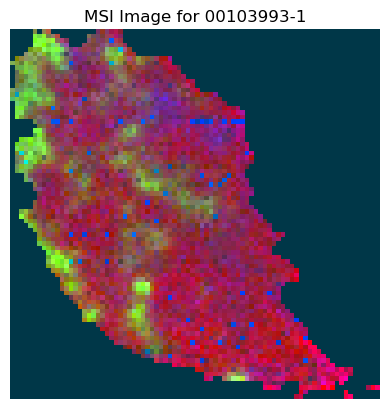

In [ ]:
plt.imshow(msi_image, cmap='gray')
plt.axis('off')
plt.title(f"MSI Image for {SAMPLE_ID}")